# Maybank (1155.KL) Trading Signal Prediction with XGBoost
### Using FBM KLCI (Top 30 Malaysian companies index, which includes Maybank) as a market-context feature

This notebook builds a **3-class classifier** that predicts a next-day trading action for **Maybank (1155.KL)**:

| Class | Meaning | Trigger |
|---|---|---|
| `0` | **Hold** | next-day return stays inside a neutral band |
| `1` | **Buy**  | next-day return is meaningfully positive |
| `2` | **Sell** | next-day return is meaningfully negative |

using:
- Maybank's own OHLCV-derived technical features (momentum, trend, volatility, volume)
- FBM KLCI (`^KLSE`) index-derived features, since Maybank is a large constituent of the index and broad market direction often leads/confirms individual stock moves

**Structure of this notebook:**
1. Data Cleaning
2. Time-Series Data Split (Train / Valid / Test = 7:2:1)
3. Feature Engineering
4. XGBoost Hyperparameter Tuning (with early stopping)
5. Baseline Comparison
6. Full Model Evaluation Results
7. Test (Production) Score
8. Mock Trading Simulation

> **Note:** This notebook downloads live data via `yfinance`, so it must be run in an environment with internet access (e.g. locally or on Google Colab).

## 0. Setup & Installs

Install/import all required libraries. `ta` is used for technical-analysis indicators, `xgboost` for the classifier.

In [ ]:
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ta
import yfinance as yf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [104]:
# --- Config ---
MAYBANK_TICKER = "1155.KL"  # Maybank on Bursa Malaysia
KLCI_TICKER = "^KLSE"  # FTSE Bursa Malaysia KLCI (top 30 companies, incl. Maybank)

START_DATE = "2010-01-01"
END_DATE = None  # None = up to today

print(f"Maybank ticker : {MAYBANK_TICKER}")
print(f"FBM KLCI ticker: {KLCI_TICKER}")

Maybank ticker : 1155.KL
FBM KLCI ticker: ^KLSE


## Download Raw Data

We pull daily OHLCV data for both Maybank and the FBM KLCI index. The KLCI series will later be merged in as *contextual/market* features — Maybank is one of the index's largest constituents, so the index's own momentum/trend can carry predictive signal for the individual stock.

In [105]:
maybank_raw = yf.download(
    MAYBANK_TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False
)
klci_raw = yf.download(
    KLCI_TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False
)

# yfinance sometimes returns MultiIndex columns for a single ticker - flatten if needed
if isinstance(maybank_raw.columns, pd.MultiIndex):
    maybank_raw.columns = maybank_raw.columns.get_level_values(0)
if isinstance(klci_raw.columns, pd.MultiIndex):
    klci_raw.columns = klci_raw.columns.get_level_values(0)

print("Maybank shape:", maybank_raw.shape)
print("KLCI shape   :", klci_raw.shape)
maybank_raw.tail()

Maybank shape: (4113, 6)
KLCI shape   : (4089, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-09-07,10.58,10.58,10.64,10.56,10.56,11027500
2026-09-08,10.54,10.54,10.60,10.54,10.58,8389200
2026-09-09,10.46,10.46,10.56,10.46,10.56,17425300
2026-09-10,10.46,10.46,10.54,10.46,10.50,8373300
2026-09-11,10.38,10.38,10.48,10.38,10.48,11956900


## 1. Data Cleaning

Requirement: **drop rows that have null values in OHLCV (Open, High, Low, Close, Volume)**, for both Maybank and the FBM KLCI series, before any feature engineering happens. We also align both series on the trading calendar (inner join on date), since holidays can differ slightly and we need matched dates when merging KLCI features onto Maybank rows.

In [106]:
def clean_ohlcv(df, name):
    ohlcv_cols = ["Open", "High", "Low", "Close", "Volume"]
    before = len(df)
    df = df.copy()

    # Keep only rows where all OHLCV columns are present and non-null
    df = df.dropna(subset=ohlcv_cols)

    # Defensive: drop any rows where volume is 0 (non-trading / bad data) which can break pct_change features
    df = df[df["Volume"] > 0]

    after = len(df)
    print(
        f"[{name}] Dropped {before - after} rows with null/invalid OHLCV out of {before} total rows."
    )
    return df


maybank_clean = clean_ohlcv(maybank_raw, "Maybank")
klci_clean = clean_ohlcv(klci_raw, "FBM KLCI")

# Align both series on shared trading dates (inner join) so KLCI features line up 1-to-1 with Maybank rows
common_dates = maybank_clean.index.intersection(klci_clean.index)
maybank_clean = maybank_clean.loc[common_dates].sort_index()
klci_clean = klci_clean.loc[common_dates].sort_index()

print(f"\nAligned shape (both series): {maybank_clean.shape}")
assert maybank_clean.isna().sum().sum() == 0, "Nulls remain in Maybank OHLCV!"
assert klci_clean.isna().sum().sum() == 0, "Nulls remain in KLCI OHLCV!"
print("No nulls remain in either OHLCV dataset. ✅")

[Maybank] Dropped 32 rows with null/invalid OHLCV out of 4113 total rows.
[FBM KLCI] Dropped 16 rows with null/invalid OHLCV out of 4089 total rows.

Aligned shape (both series): (4066, 6)
No nulls remain in either OHLCV dataset. ✅


## 2. Time-Series Data Split (Train : Valid : Test = 7 : 2 : 1)

Because this is time-series data, we **never shuffle**. We split chronologically:

- **Train (70%)** — used to fit the model
- **Valid (20%)** — used for hyperparameter tuning / early stopping
- **Test (10%)** — held out completely, touched only once at the end, to simulate genuine "production" performance on unseen future data

We compute the split **cutoff dates** here on the cleaned, aligned date index. The actual feature matrix (built in Section 3) will be sliced using these same cutoff dates, so there is no leakage of future information into earlier splits (e.g. no rolling-window feature is allowed to peek across the boundary in a way that uses test labels).

In [107]:
n = len(maybank_clean)
train_end_idx = int(n * 0.7)
valid_end_idx = int(n * 0.9)  # 0.7 + 0.2

train_dates = maybank_clean.index[:train_end_idx]
valid_dates = maybank_clean.index[train_end_idx:valid_end_idx]
test_dates = maybank_clean.index[valid_end_idx:]

print(f"Total rows : {n}")
print(
    f"Train      : {len(train_dates):>5} rows  ({train_dates.min().date()} -> {train_dates.max().date()})"
)
print(
    f"Valid      : {len(valid_dates):>5} rows  ({valid_dates.min().date()} -> {valid_dates.max().date()})"
)
print(
    f"Test (prod): {len(test_dates):>5} rows  ({test_dates.min().date()} -> {test_dates.max().date()})"
)
print(
    f"\nRatio check -> train: {len(train_dates) / n:.2%}, valid: {len(valid_dates) / n:.2%}, test: {len(test_dates) / n:.2%}"
)

Total rows : 4066
Train      :  2846 rows  (2010-01-04 -> 2021-09-10)
Valid      :   813 rows  (2021-09-13 -> 2025-01-08)
Test (prod):   407 rows  (2025-01-09 -> 2026-09-11)

Ratio check -> train: 70.00%, valid: 20.00%, test: 10.01%


## 3. Feature Engineering

We build two feature blocks:

1. **Maybank technical features** — momentum (RSI, MACD), trend/moving-average ratios, ADX, rolling return mean/std, and volume features (exactly as specified).
2. **FBM KLCI market-context features** — the *same* style of technical features computed on the index itself, prefixed `klci_`, then merged onto the Maybank rows by date. Since Maybank is a top constituent of the KLCI, the index's own trend/momentum acts as a broad market signal that can help/confirm Maybank's own direction.

All rolling/indicator calculations are done on the **full continuous price history** (not per-split) since these are standard causal (backward-looking only) technical indicators — each value at time *t* only uses data up to and including *t*, so there is no leakage across the train/valid/test boundaries we defined above.

In [108]:
def build_technical_features(df, prefix=""):
    """Builds the requested technical-analysis feature set on a single OHLCV dataframe.
    Returns a DataFrame of features only (same index as df), optionally prefixed
    (used to distinguish KLCI features from Maybank features after merging).
    """
    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    feat = pd.DataFrame(index=df.index)

    # --- Momentum ---
    feat["rsi_14"] = ta.momentum.RSIIndicator(close, window=14).rsi()

    macd = ta.trend.MACD(close)
    feat["macd"] = macd.macd()
    feat["macd_signal"] = macd.macd_signal()
    feat["macd_diff"] = macd.macd_diff()

    # --- Trend / moving averages (ratios, not raw price, for stationarity) ---
    sma_5 = ta.trend.SMAIndicator(close, window=5).sma_indicator()
    sma_10 = ta.trend.SMAIndicator(close, window=10).sma_indicator()
    sma_20 = ta.trend.SMAIndicator(close, window=20).sma_indicator()
    sma_50 = ta.trend.SMAIndicator(close, window=50).sma_indicator()

    feat["price_to_sma5"] = close / sma_5 - 1
    feat["price_to_sma10"] = close / sma_10 - 1
    feat["price_to_sma20"] = close / sma_20 - 1
    feat["price_to_sma50"] = close / sma_50 - 1
    feat["sma20_to_sma50"] = sma_20 / sma_50 - 1

    feat["adx_14"] = ta.trend.ADXIndicator(high, low, close, window=14).adx()

    ret = close.pct_change()
    for window in [5, 10, 20]:
        feat[f"ret_mean_{window}"] = ret.rolling(window).mean()
        feat[f"ret_std_{window}"] = ret.rolling(window).std()

    # --- Volume ---
    feat["volume_change"] = volume.pct_change()
    feat["volume_sma_ratio"] = volume / volume.rolling(20).mean() - 1

    if prefix:
        feat = feat.add_prefix(prefix)

    return feat


maybank_feat = build_technical_features(maybank_clean)  # e.g. rsi_14, macd, ...
klci_feat = build_technical_features(
    klci_clean, prefix="klci_"
)  # e.g. klci_rsi_14, klci_macd, ...

print("Maybank feature columns:", list(maybank_feat.columns))
print("\nKLCI feature columns   :", list(klci_feat.columns))

Maybank feature columns: ['rsi_14', 'macd', 'macd_signal', 'macd_diff', 'price_to_sma5', 'price_to_sma10', 'price_to_sma20', 'price_to_sma50', 'sma20_to_sma50', 'adx_14', 'ret_mean_5', 'ret_std_5', 'ret_mean_10', 'ret_std_10', 'ret_mean_20', 'ret_std_20', 'volume_change', 'volume_sma_ratio']

KLCI feature columns   : ['klci_rsi_14', 'klci_macd', 'klci_macd_signal', 'klci_macd_diff', 'klci_price_to_sma5', 'klci_price_to_sma10', 'klci_price_to_sma20', 'klci_price_to_sma50', 'klci_sma20_to_sma50', 'klci_adx_14', 'klci_ret_mean_5', 'klci_ret_std_5', 'klci_ret_mean_10', 'klci_ret_std_10', 'klci_ret_mean_20', 'klci_ret_std_20', 'klci_volume_change', 'klci_volume_sma_ratio']


In [109]:
# Merge KLCI (market-context) features onto Maybank rows by date, plus a couple of direct
# Maybank-vs-market relative features, which is exactly where the KLCI adds value: relative strength.
features = maybank_feat.join(klci_feat, how="inner")

# Relative-strength features: how Maybank's own return compares to the broader market's return
maybank_ret = maybank_clean["Close"].pct_change()
klci_ret = klci_clean["Close"].pct_change()
features["maybank_vs_klci_ret_1d"] = maybank_ret - klci_ret
features["maybank_vs_klci_ret_5d"] = (
    maybank_ret.rolling(5).mean() - klci_ret.rolling(5).mean()
)
features["maybank_vs_klci_rsi_diff"] = maybank_feat["rsi_14"] - klci_feat["klci_rsi_14"]

print("Final combined feature matrix shape (pre-NaN-drop):", features.shape)
features.tail()

Final combined feature matrix shape (pre-NaN-drop): (4066, 39)


,rsi_14,macd,macd_signal,macd_diff,price_to_sma5,price_to_sma10,price_to_sma20,price_to_sma50,sma20_to_sma50,adx_14,ret_mean_5,ret_std_5,ret_mean_10,ret_std_10,ret_mean_20,ret_std_20,volume_change,volume_sma_ratio,klci_rsi_14,klci_macd,klci_macd_signal,klci_macd_diff,klci_price_to_sma5,klci_price_to_sma10,klci_price_to_sma20,klci_price_to_sma50,klci_sma20_to_sma50,klci_adx_14,klci_ret_mean_5,klci_ret_std_5,klci_ret_mean_10,klci_ret_std_10,klci_ret_mean_20,klci_ret_std_20,klci_volume_change,klci_volume_sma_ratio,maybank_vs_klci_ret_1d,maybank_vs_klci_ret_5d,maybank_vs_klci_rsi_diff
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-09-07,43.605405,-0.056896,-0.061686,0.004791,0.000378,-0.002451,-0.002734,-0.018116,-0.015424,10.287220,-0.001866,0.005786,0.000026,0.007584,-0.001009,0.006406,-0.056059,-0.465794,46.129882,-1.737917,2.197664,-3.935582,0.003118,-0.005126,-0.007927,0.000811,0.008808,23.731369,-0.001261,0.008322,-0.001248,0.006805,-0.000634,0.005274,-0.175717,-0.400125,-0.002023,-0.000606,-2.524478
2026-09-08,41.210060,-0.058040,-0.060957,0.002917,-0.003027,-0.005660,-0.005848,-0.021356,-0.015599,9.567405,-0.000375,0.003109,-0.000541,0.007641,-0.000642,0.005994,-0.239247,-0.581100,45.950067,-2.127817,1.332568,-3.460385,0.001266,-0.004076,-0.007539,0.000039,0.007636,23.185619,0.001630,0.003746,-0.001258,0.006803,-0.000605,0.005275,0.384984,-0.155164,-0.003553,-0.002006,-4.740008
2026-09-09,36.850112,-0.064656,-0.061697,-0.002959,-0.007967,-0.012276,-0.012462,-0.028170,-0.015906,9.797732,-0.002651,0.003446,-0.000923,0.007911,-0.000928,0.006189,1.077111,-0.148218,45.920383,-2.413836,0.583287,-2.997124,0.000577,-0.002837,-0.006970,-0.000561,0.006454,22.216165,0.000659,0.003317,-0.001253,0.006804,-0.000596,0.005276,0.398401,0.149888,-0.007555,-0.003310,-9.070271
2026-09-10,36.850112,-0.069103,-0.063178,-0.005925,-0.005703,-0.009845,-0.011996,-0.027592,-0.015785,10.011606,-0.002273,0.003648,-0.002438,0.005605,-0.000459,0.005862,-0.519475,-0.574736,41.663660,-3.314003,-0.196171,-3.117832,-0.003453,-0.005479,-0.011336,-0.006183,0.005212,22.057413,-0.001118,0.003620,-0.002471,0.006221,-0.000741,0.005362,-0.158721,-0.034951,0.005145,-0.001156,-4.813548
2026-09-11,32.822735,-0.078182,-0.066179,-0.012003,-0.009920,-0.015180,-0.018533,-0.034526,-0.016296,11.004886,-0.003425,0.004340,-0.002270,0.005397,-0.001031,0.005982,0.427979,-0.394406,34.360034,-5.479617,-1.252860,-4.226757,-0.011960,-0.013267,-0.020665,-0.017469,0.003263,23.133562,-0.002500,0.005741,-0.003182,0.006784,-0.001584,0.005591,-0.060923,-0.085044,0.003363,-0.000925,-1.537299


### Target variable — 3-class trading signal

Instead of a plain up/down label, we define a **3-class trading action** based on the *magnitude* of the next-day return against a configurable threshold band:

- **`1` = UP**  → next-day return > `+UP_THRESHOLD`
- **`2` = DOWN** → next-day return < `-DOWN_THRESHOLD`
- **`0` = STILL** → next-day return falls inside the band (move too small to act on)

As before, this is a forward-looking label, so it's shifted one day relative to the features — at day *t* we only use information available up to and including day *t* to decide the action for day *t+1* (no lookahead bias).

`UP_THRESHOLD` / `DOWN_THRESHOLD` are adjustable: tighter thresholds produce more Buy/Sell rows (more balanced classes, noisier signal), wider thresholds produce more Hold rows (closer to realistic "don't act on noise" behavior).

In [110]:
UP_THRESHOLD = 0.005  # next-day return above +0.5% -> UP
DOWN_THRESHOLD = -0.005  # next-day return below -0.5% -> DOWN

LABEL_NAMES = {0: "STILL", 1: "UP", 2: "DOWN"}

next_day_return = maybank_clean["Close"].pct_change().shift(-1)

target = pd.Series(
    0, index=maybank_clean.index, name="target_signal"
)  # default: 0 = STILL
target[next_day_return > UP_THRESHOLD] = 1  # UP
target[next_day_return < DOWN_THRESHOLD] = 2  # DOWN
target[next_day_return.isna()] = (
    np.nan
)  # last row has no "tomorrow" -> undefined, not STILL

dataset = features.join(target, how="inner")

# Drop rows with NaNs generated by rolling-window warm-up periods (e.g. first 50 rows for SMA-50)
# and the very last row (its target is undefined because there's no "tomorrow" to compare to)
before = len(dataset)
dataset = dataset.dropna()
dataset["target_signal"] = dataset["target_signal"].astype(int)
after = len(dataset)
print(
    f"Dropped {before - after} warm-up/edge rows with NaNs from indicator rolling windows."
)
print(f"Final modeling dataset shape: {dataset.shape}")

class_dist = (
    dataset["target_signal"]
    .value_counts(normalize=True)
    .rename("proportion")
    .sort_index()
)
class_dist.index = class_dist.index.map(LABEL_NAMES)
class_dist

Dropped 50 warm-up/edge rows with NaNs from indicator rolling windows.
Final modeling dataset shape: (4016, 40)


target_signal
STILL    0.611803
UP       0.200697
DOWN     0.187500
Name: proportion, dtype: float64

### Apply the Train / Valid / Test split (from Section 2) to the final feature matrix

We re-derive the split on the **post-NaN-drop** dataset using the same 70/20/10 chronological logic, since dropping warm-up rows shifts the usable date range slightly.

In [111]:
n_final = len(dataset)
train_end = int(n_final * 0.7)
valid_end = int(n_final * 0.9)

train_df = dataset.iloc[:train_end]
valid_df = dataset.iloc[train_end:valid_end]
test_df  = dataset.iloc[valid_end:]

feature_cols = [c for c in dataset.columns if c != "target_signal"]

X_train, y_train = train_df[feature_cols], train_df["target_signal"]
X_valid, y_valid = valid_df[feature_cols], valid_df["target_signal"]
X_test,  y_test  = test_df[feature_cols],  test_df["target_signal"]

# --- Compute class balance weights to prevent collapsing into 'Hold' ---
sample_weights_train = compute_sample_weight("balanced", y_train)
sample_weights_valid = compute_sample_weight("balanced", y_valid)

print(f"Train: {X_train.shape}  ({train_df.index.min().date()} -> {train_df.index.max().date()})")
print(f"Valid: {X_valid.shape}  ({valid_df.index.min().date()} -> {valid_df.index.max().date()})")
print(f"Test : {X_test.shape}  ({test_df.index.min().date()} -> {test_df.index.max().date()})  <- production hold-out")

def class_balance_str(y):
    counts = y.value_counts(normalize=True).sort_index()
    return ", ".join(f"{LABEL_NAMES[k]}: {v:.1%}" for k, v in counts.items())

print(f"\nTrain class balance -> {class_balance_str(y_train)}")
print(f"Valid class balance -> {class_balance_str(y_valid)}")
print(f"Test  class balance -> {class_balance_str(y_test)}")

Train: (2811, 39)  (2010-03-18 -> 2021-10-01)
Valid: (803, 39)  (2021-10-04 -> 2025-01-14)
Test : (402, 39)  (2025-01-15 -> 2026-09-10)  <- production hold-out

Train class balance -> STILL: 60.9%, UP: 20.0%, DOWN: 19.1%
Valid class balance -> STILL: 67.4%, UP: 17.9%, DOWN: 14.7%
Test  class balance -> STILL: 51.0%, UP: 24.6%, DOWN: 24.4%


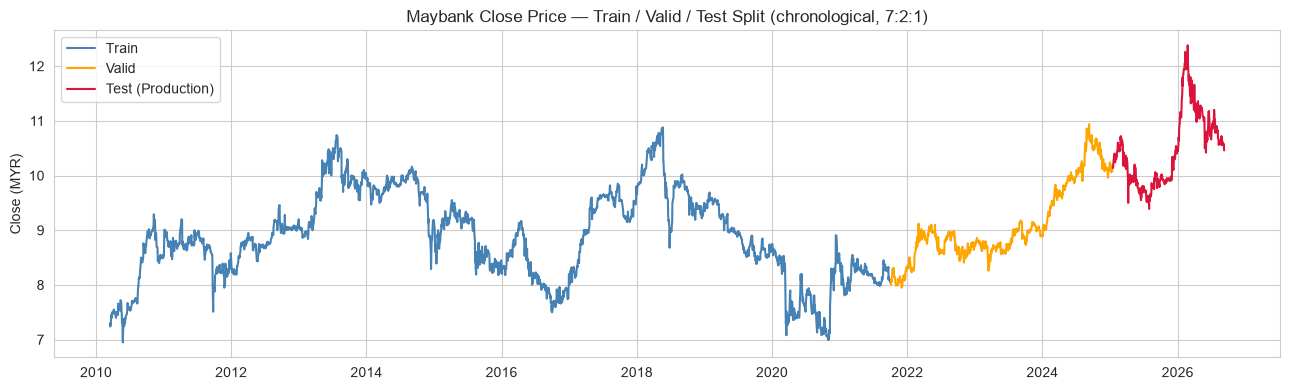

In [112]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    train_df.index,
    maybank_clean.loc[train_df.index, "Close"],
    label="Train",
    color="steelblue",
)
ax.plot(
    valid_df.index,
    maybank_clean.loc[valid_df.index, "Close"],
    label="Valid",
    color="orange",
)
ax.plot(
    test_df.index,
    maybank_clean.loc[test_df.index, "Close"],
    label="Test (Production)",
    color="crimson",
)
ax.set_title("Maybank Close Price — Train / Valid / Test Split (chronological, 7:2:1)")
ax.set_ylabel("Close (MYR)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. XGBoost Hyperparameter Tuning

We tune the `XGBClassifier` with a manual/randomized grid search over the validation set, using:
- `early_stopping_rounds` (fit on train, monitored on valid, stops if valid performance doesn't improve)
- `learning_rate`
- `n_estimators` (upper bound — early stopping finds the actual best number of trees per configuration)
- `max_depth`, `subsample`, `colsample_bytree`, `min_child_weight` for regularization / generalization control

We select the configuration with the **highest validation accuracy**, and record the best number of estimators (boosting rounds) discovered via early stopping.

In [113]:
param_grid = {
    "learning_rate":    [0.02, 0.05],
    "max_depth":        [2, 3],
    "subsample":        [0.7, 0.85],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [5, 15, 30],
    "gamma":            [0.1, 0.5],
}

MAX_ESTIMATORS = 500       # ceiling; early stopping finds optimal tree count
EARLY_STOPPING_ROUNDS = 25

keys, values = zip(*param_grid.items())
all_combos = [dict(zip(keys, v)) for v in product(*values)]
print(f"Total hyperparameter combinations to try: {len(all_combos)}")

Total hyperparameter combinations to try: 96


In [114]:
results_log = []
best_score = -1
best_model = None
best_params = None
best_n_estimators = None

for i, params in enumerate(all_combos):
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=MAX_ESTIMATORS,
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        min_child_weight=params["min_child_weight"],
        gamma=params["gamma"],
        reg_alpha=0.5,
        reg_lambda=2.0,
        eval_metric="mlogloss",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    model.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_valid, y_valid)],
        sample_weight_eval_set=[sample_weights_valid],
        verbose=False,
    )

    valid_pred = model.predict(X_valid)
    valid_f1   = f1_score(y_valid, valid_pred, average="macro", zero_division=0)
    valid_acc  = accuracy_score(y_valid, valid_pred)
    best_iter  = model.best_iteration if hasattr(model, "best_iteration") and model.best_iteration is not None else model.n_estimators

    results_log.append({
        **params,
        "best_n_estimators": best_iter,
        "valid_f1_score": valid_f1,
        "valid_accuracy": valid_acc,
    })

    if valid_f1 > best_score:
        best_score = valid_f1
        best_model = model
        best_params = params
        best_n_estimators = best_iter

    if (i + 1) % 12 == 0 or (i + 1) == len(all_combos):
        print(f"[{i+1}/{len(all_combos)}] tried -> current best valid macro F1: {best_score:.4f}")

print("\n" + "="*60)
print("BEST HYPERPARAMETERS FOUND (by validation macro F1)")
print("="*60)
for k, v in best_params.items():
    print(f"  {k:>18}: {v}")
print(f"  {'best_n_estimators':>18}: {best_n_estimators}  (found via early_stopping_rounds={EARLY_STOPPING_ROUNDS})")
print(f"  {'valid_f1_score':>18}: {best_score:.4f}")

[12/96] tried -> current best valid macro F1: 0.4124
[24/96] tried -> current best valid macro F1: 0.4135
[36/96] tried -> current best valid macro F1: 0.4266
[48/96] tried -> current best valid macro F1: 0.4266
[60/96] tried -> current best valid macro F1: 0.4266
[72/96] tried -> current best valid macro F1: 0.4266
[84/96] tried -> current best valid macro F1: 0.4266
[96/96] tried -> current best valid macro F1: 0.4266

BEST HYPERPARAMETERS FOUND (by validation macro F1)
       learning_rate: 0.02
           max_depth: 3
           subsample: 0.7
    colsample_bytree: 0.7
    min_child_weight: 15
               gamma: 0.5
   best_n_estimators: 128  (found via early_stopping_rounds=25)
      valid_f1_score: 0.4266


In [115]:
tuning_results_df = (
    pd.DataFrame(results_log)
    .sort_values("valid_f1_score", ascending=False)
    .reset_index(drop=True)
)
tuning_results_df.head(10)

,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,gamma,best_n_estimators,valid_f1_score,valid_accuracy
0,0.02,3,0.70,0.7,15,0.5,128,0.426591,0.552927
1,0.02,3,0.70,0.7,15,0.1,129,0.426266,0.552927
2,0.05,3,0.85,0.9,30,0.5,55,0.422403,0.554172
3,0.05,3,0.70,0.7,5,0.1,55,0.422386,0.555417
4,0.02,3,0.85,0.9,5,0.1,85,0.422359,0.551681
5,0.02,3,0.85,0.7,15,0.5,126,0.421123,0.551681
6,0.02,3,0.85,0.7,15,0.1,126,0.421083,0.551681
7,0.05,2,0.70,0.7,5,0.1,58,0.420810,0.566625
8,0.05,2,0.70,0.7,5,0.5,58,0.420810,0.566625
9,0.02,3,0.85,0.7,30,0.5,105,0.420752,0.551681


### Refit the final model

We refit an `XGBClassifier` using the best hyperparameters, with `n_estimators` fixed to the optimal boosting round count found above (rather than relying on early stopping again), trained on Train and validated against Valid one more time for a clean final artifact.

In [116]:
final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=best_n_estimators,
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    min_child_weight=best_params["min_child_weight"],
    gamma=best_params.get("gamma", 0.1),
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(X_train, y_train, sample_weight=sample_weights_train)
print("Final model trained with tuned hyperparameters and balanced sample weights.")

Final model trained with tuned hyperparameters and balanced sample weights.


## 5. Baseline Comparison

With 3 classes, a naive baseline that always predicts a fixed class (e.g. always "Buy") is a sense check for whether the model is doing any better than blindly exploiting whichever class happens to dominate. We use the **majority class observed in the training data** (typically "Hold", since large single-day moves that clear the threshold band are relatively rare) as the baseline prediction for every row.

In [117]:
majority_class = int(y_train.mode()[0])
majority_class_name = LABEL_NAMES[majority_class]
print(
    f"Majority class in training data: '{majority_class_name}' ({(y_train == majority_class).mean():.2%} of train rows)"
)

baseline_predictions = np.full(len(y_test), majority_class, dtype=int)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(
    f"\nBaseline (always predict '{majority_class_name}') — Test accuracy: {baseline_accuracy:.4f}"
)

# Also report baseline on train/valid for context
print(
    f"Baseline accuracy on Train: {accuracy_score(y_train, np.full(len(y_train), majority_class, dtype=int)):.4f}"
)
print(
    f"Baseline accuracy on Valid: {accuracy_score(y_valid, np.full(len(y_valid), majority_class, dtype=int)):.4f}"
)

Majority class in training data: 'STILL' (60.87% of train rows)

Baseline (always predict 'STILL') — Test accuracy: 0.5100
Baseline accuracy on Train: 0.6087
Baseline accuracy on Valid: 0.6737


## 6. Full Model Performance Results

Comprehensive evaluation across Train, Valid, and Test sets: accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and feature importance.

In [118]:
CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = [LABEL_NAMES[c] for c in CLASS_LABELS]  # ["No movement", "UP", "Down"]


def evaluate(model, X, y, split_name):
    pred = model.predict(X)
    pred_prob = model.predict_proba(X)  # shape (n_samples, 3)

    metrics = {
        "split": split_name,
        "accuracy": accuracy_score(y, pred),
        "precision_macro": precision_score(y, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(
            y, pred_prob, multi_class="ovr", average="macro"
        ),
    }
    return metrics, pred, pred_prob


train_metrics, train_pred, train_prob = evaluate(final_model, X_train, y_train, "Train")
valid_metrics, valid_pred, valid_prob = evaluate(final_model, X_valid, y_valid, "Valid")
test_metrics, test_pred, test_prob = evaluate(
    final_model, X_test, y_test, "Test (Production)"
)

results_summary = pd.DataFrame([train_metrics, valid_metrics, test_metrics]).set_index(
    "split"
)
results_summary.round(4)

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr_macro
split,,,,,
Train,0.5987,0.5368,0.5637,0.5457,0.7527
Valid,0.5542,0.4253,0.4383,0.4289,0.6010
Test (Production),0.4328,0.4147,0.4198,0.4099,0.6198


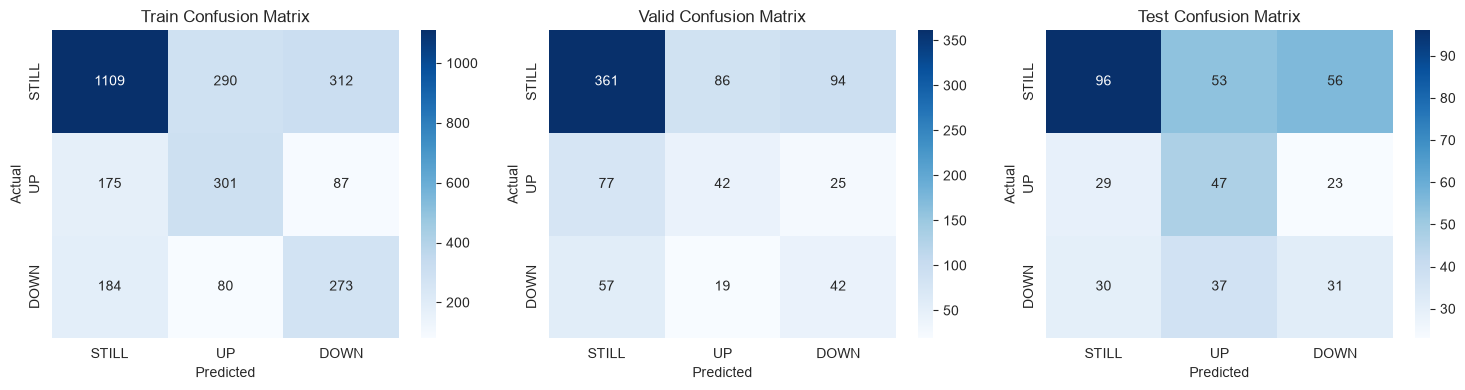

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_true, pred) in zip(
    axes,
    [
        ("Train", y_train, train_pred),
        ("Valid", y_valid, valid_pred),
        ("Test", y_test, test_pred),
    ],
):
    cm = confusion_matrix(y_true, pred, labels=CLASS_LABELS)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [120]:
print("=== TRAIN classification report ===")
print(
    classification_report(
        y_train,
        train_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== VALID classification report ===")
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== TEST (Production) classification report ===")
print(
    classification_report(
        y_test,
        test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

=== TRAIN classification report ===
              precision    recall  f1-score   support

       STILL       0.76      0.65      0.70      1711
          UP       0.45      0.53      0.49       563
        DOWN       0.41      0.51      0.45       537

    accuracy                           0.60      2811
   macro avg       0.54      0.56      0.55      2811
weighted avg       0.63      0.60      0.61      2811

=== VALID classification report ===
              precision    recall  f1-score   support

       STILL       0.73      0.67      0.70       541
          UP       0.29      0.29      0.29       144
        DOWN       0.26      0.36      0.30       118

    accuracy                           0.55       803
   macro avg       0.43      0.44      0.43       803
weighted avg       0.58      0.55      0.57       803

=== TEST (Production) classification report ===
              precision    recall  f1-score   support

       STILL       0.62      0.47      0.53       205
         

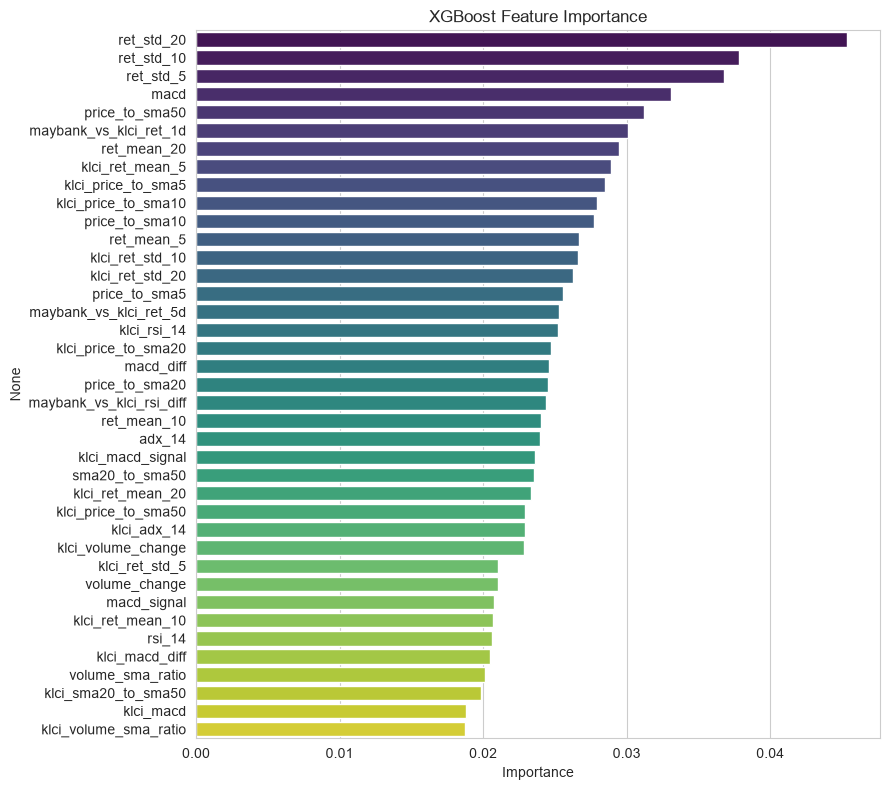


Share of total importance coming from FBM KLCI / relative-to-market features: 50.31%


In [121]:
# Feature importance — which signals (Maybank technicals vs KLCI market-context) matter most
importance = pd.Series(
    final_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

klci_importance_share = importance[
    [c for c in importance.index if c.startswith("klci_") or "vs_klci" in c]
].sum()
print(
    f"\nShare of total importance coming from FBM KLCI / relative-to-market features: {klci_importance_share / importance.sum():.2%}"
)

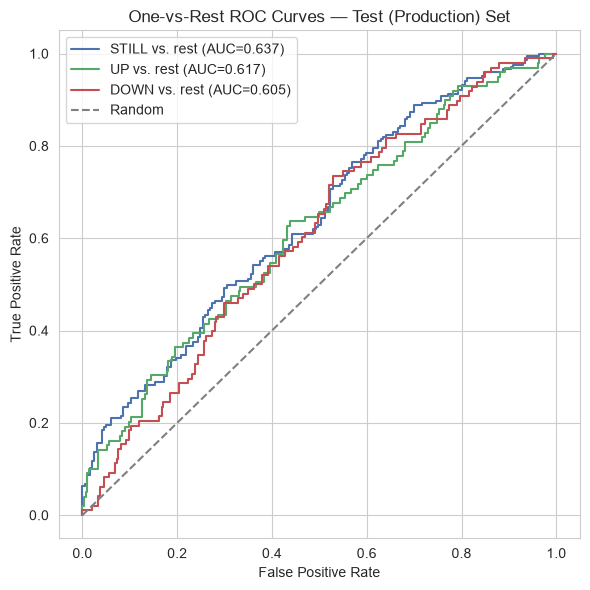

In [122]:
# One-vs-Rest ROC curves (one per class) on the Test (production) set — with 3 classes there is
# no single ROC curve, so we plot each class against "everything else" and report its own AUC.
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=CLASS_LABELS)
colors = ["#4C72B0", "#55A868", "#C44E52"]

plt.figure(figsize=(6, 6))
for i, cls in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], test_prob[:, i])
    plt.plot(
        fpr, tpr, label=f"{LABEL_NAMES[cls]} vs. rest (AUC={auc:.3f})", color=colors[i]
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves — Test (Production) Set")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Test (Production) Score

The Test split (final 10% chronologically) was **never touched during tuning** — this is our best estimate of how the model would perform if deployed "live" going forward. We compare it directly against the majority-class baseline on the *same* Test set.

In [123]:
print("=" * 55)
print("PRODUCTION (TEST) PERFORMANCE SUMMARY")
print("=" * 55)
print(
    f"Test period          : {test_df.index.min().date()} -> {test_df.index.max().date()}"
)
print(f"Number of test days  : {len(y_test)}")
print("-" * 55)
print(f"XGBoost Model Accuracy : {test_metrics['accuracy']:.4f}")
print(
    f"Baseline Accuracy      : {baseline_accuracy:.4f}  (always predicts '{majority_class_name}')"
)
print(f"Improvement over base. : {test_metrics['accuracy'] - baseline_accuracy:+.4f}")
print("-" * 55)
print(f"Precision (macro) : {test_metrics['precision_macro']:.4f}")
print(f"Recall (macro)    : {test_metrics['recall_macro']:.4f}")
print(f"F1-score (macro)  : {test_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (OvR macro): {test_metrics['roc_auc_ovr_macro']:.4f}")
print("=" * 55)

comparison_df = pd.DataFrame(
    {
        "Model": ["XGBoost (tuned)", f"Baseline (always {majority_class_name})"],
        "Accuracy": [test_metrics["accuracy"], baseline_accuracy],
    }
)
comparison_df

PRODUCTION (TEST) PERFORMANCE SUMMARY
Test period          : 2025-01-15 -> 2026-09-10
Number of test days  : 402
-------------------------------------------------------
XGBoost Model Accuracy : 0.4328
Baseline Accuracy      : 0.5100  (always predicts 'STILL')
Improvement over base. : -0.0771
-------------------------------------------------------
Precision (macro) : 0.4147
Recall (macro)    : 0.4198
F1-score (macro)  : 0.4099
ROC-AUC (OvR macro): 0.6198


,Model,Accuracy
0,XGBoost (tuned),0.432836
1,Baseline (always STILL),0.509950


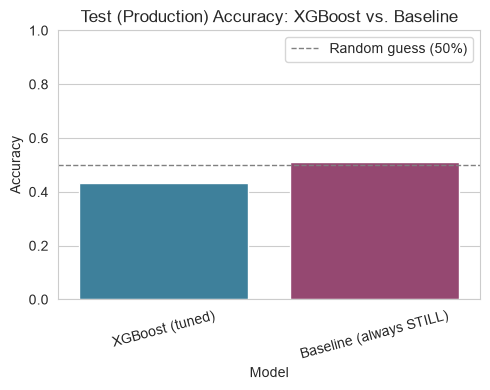

In [124]:
plt.figure(figsize=(5, 4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette=["#2E86AB", "#A23B72"])
plt.ylim(0, 1)
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1, label="Random guess (50%)")
plt.xticks(rotation=15)
plt.title("Test (Production) Accuracy: XGBoost vs. Baseline")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Mock Trading Simulation (on Test / Production Data)

With a genuine 3-way **Buy / Hold / Sell** signal, the simulation maps directly onto trading actions for each day in the Test period:

- **Buy (1)**  → go **long** for that day (capture the actual next-day return)
- **Sell (2)** → go **short** for that day (capture the *inverse* of the actual next-day return)
- **Hold (0)** → stay in **cash** for that day (0% return)

> Note: modeling "Sell" as a short position is a simplification for comparison purposes. Short-selling on Bursa Malaysia is restricted to approved securities and incurs borrowing costs/margin requirements not modeled here — in a more conservative simulation, "Sell" could instead just mean "exit to cash," which would produce a more cautious (lower-risk, lower-return) version of this same strategy.

We compare three portfolios on the Test set, all starting from the same capital:
- **XGBoost Model strategy** — acts on the tuned model's daily predictions
- **Baseline strategy** — acts on the majority-class baseline's predictions (Section 5)
- **Buy & Hold** — stays invested in Maybank for the entire test period, ignoring any signal

This is a simplified simulation — it ignores transaction costs, slippage, dividends, taxes, and realistic position sizing, and is meant only to illustrate whether the model's signal has directional value, not to be an actual backtested trading system.

In [131]:
# --- Broker Fee Config (Bursa Malaysia realistic fee: ~0.10% to 0.15% per trade) ---
BROKER_FEE = 0.001  # 0.10% (10 bps) per side (buy/sell/short/exit)
STARTING_CAPITAL = 10_000

# Actual next-day returns aligned with the test set
test_actual_returns = maybank_clean["Close"].pct_change().shift(-1).loc[test_df.index]

sim = pd.DataFrame(
    {
        "actual_return": test_actual_returns,
        "model_signal": test_pred,
        "baseline_signal": baseline_predictions,
    },
    index=test_df.index,
)


# Map 3-class signal to market position: 1 = Long (+1), 2 = Short (-1), 0 = Cash (0)
def signal_to_position(signal_series):
    return np.select(
        [signal_series == 1, signal_series == 2],
        [1, -1],
        default=0,
    )


def compute_net_strategy_returns(signal_series, actual_returns, fee_rate):
    """Calculates daily gross return, turnover cost (broker fee only when position changes),

    and final net return after fees.
    """
    position = pd.Series(signal_to_position(signal_series), index=actual_returns.index)

    # Gross return: long earns +return, short earns -return, cash earns 0
    gross_return = position * actual_returns

    # Turnover: units traded whenever position changes relative to previous day
    # e.g., Cash -> Long = 1 trade; Long -> Short = 2 trades (close long + open short)
    prev_position = position.shift(1).fillna(0)
    turnover = (position - prev_position).abs()

    # Transaction fees deducted on traded days
    tx_cost = turnover * fee_rate
    net_return = gross_return - tx_cost

    return gross_return, tx_cost, net_return


# Model Strategy
(
    sim["model_gross_return"],
    sim["model_fee_cost"],
    sim["model_strategy_return"],
) = compute_net_strategy_returns(sim["model_signal"], sim["actual_return"], BROKER_FEE)

# Baseline Strategy
(
    sim["baseline_gross_return"],
    sim["baseline_fee_cost"],
    sim["baseline_strategy_return"],
) = compute_net_strategy_returns(
    sim["baseline_signal"], sim["actual_return"], BROKER_FEE
)

# Buy & Hold (Single entry fee on Day 1, no further trades)
sim["UP_STILL_return"] = sim["actual_return"].copy()
sim.loc[sim.index[0], "UP_STILL_return"] -= BROKER_FEE

# Compounded Equity Curves
sim["model_equity"] = STARTING_CAPITAL * (1 + sim["model_strategy_return"]).cumprod()
sim["baseline_equity"] = (
    STARTING_CAPITAL * (1 + sim["baseline_strategy_return"]).cumprod()
)
sim["UP_STILL_equity"] = STARTING_CAPITAL * (1 + sim["UP_STILL_return"]).cumprod()

sim["model_signal_label"] = sim["model_signal"].map(LABEL_NAMES)

total_model_trades = int(
    (
        signal_to_position(sim["model_signal"])
        != pd.Series(signal_to_position(sim["model_signal"])).shift(1).fillna(0)
    ).sum()
)
print("=== TRADING SIMULATION WITH BROKER FEES ===")
print(f"Fee per trade side   : {BROKER_FEE:.2%} (10 bps)")
print(f"Total model trades   : {total_model_trades} trades")
print(
    f"Total fees paid      : MYR {sim['model_fee_cost'].sum() * STARTING_CAPITAL:.2f}"
)
print("\nModel signal distribution on Test set:")
print(sim["model_signal_label"].value_counts())
sim.tail()

=== TRADING SIMULATION WITH BROKER FEES ===
Fee per trade side   : 0.10% (10 bps)
Total model trades   : 128 trades
Total fees paid      : MYR 1830.00

Model signal distribution on Test set:
model_signal_label
STILL    155
UP       137
DOWN     110
Name: count, dtype: int64


,actual_return,model_signal,baseline_signal,model_gross_return,model_fee_cost,model_strategy_return,baseline_gross_return,baseline_fee_cost,baseline_strategy_return,UP_STILL_return,model_equity,baseline_equity,UP_STILL_equity,model_signal_label
Date,,,,,,,,,,,,,,
2026-09-04,0.001894,0,0,0.000000,0.000,0.000000,0.0,0.0,0.0,0.001894,11152.647321,10000.0,10423.490696,STILL
2026-09-07,-0.003781,0,0,-0.000000,0.000,-0.000000,-0.0,0.0,-0.0,-0.003781,11152.647321,10000.0,10384.082451,STILL
2026-09-08,-0.007590,0,0,-0.000000,0.000,-0.000000,-0.0,0.0,-0.0,-0.007590,11152.647321,10000.0,10305.265961,STILL
2026-09-09,0.000000,1,0,0.000000,0.001,-0.001000,0.0,0.0,0.0,0.000000,11141.494674,10000.0,10305.265961,UP
2026-09-10,-0.007648,2,0,0.007648,0.002,0.005648,-0.0,0.0,-0.0,-0.007648,11204.423800,10000.0,10226.449471,DOWN


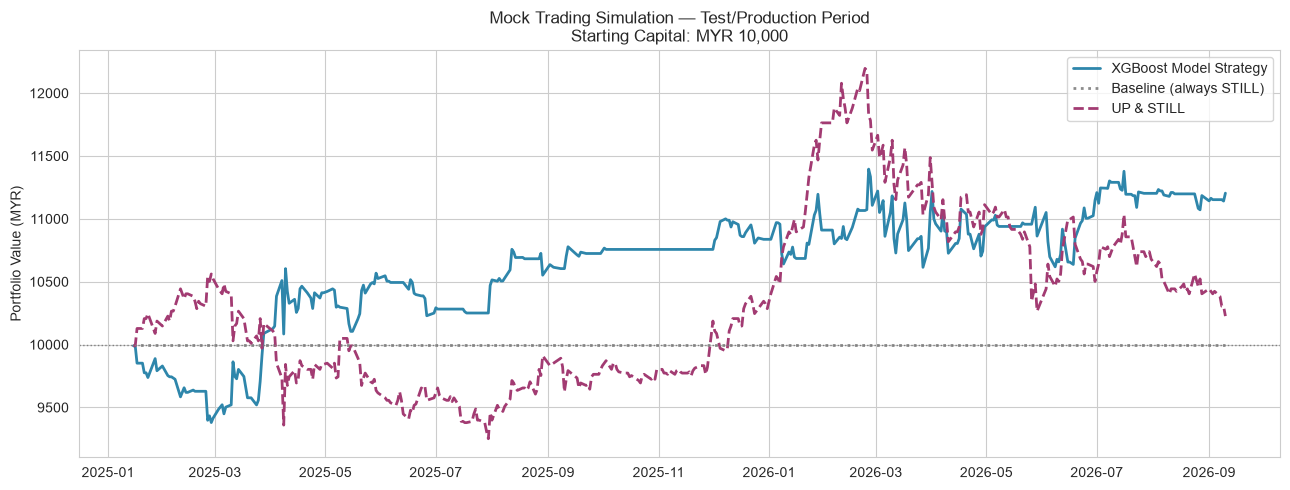

In [132]:
plt.figure(figsize=(13, 5))
plt.plot(
    sim.index,
    sim["model_equity"],
    label="XGBoost Model Strategy",
    color="#2E86AB",
    linewidth=2,
)
plt.plot(
    sim.index,
    sim["baseline_equity"],
    label=f"Baseline (always {majority_class_name})",
    color="#8C8C8C",
    linewidth=2,
    linestyle=":",
)
plt.plot(
    sim.index,
    sim["UP_STILL_equity"],
    label="UP & STILL",
    color="#A23B72",
    linewidth=2,
    linestyle="--",
)
plt.axhline(STARTING_CAPITAL, color="gray", linewidth=1, linestyle=":")
plt.title(
    f"Mock Trading Simulation — Test/Production Period\nStarting Capital: MYR {STARTING_CAPITAL:,}"
)
plt.ylabel("Portfolio Value (MYR)")
plt.legend()
plt.tight_layout()
plt.show()

In [133]:
def sim_summary(returns, equity, name):
    total_return = equity.iloc[-1] / STARTING_CAPITAL - 1
    n_days = len(returns)
    ann_factor = 252 / n_days
    cagr = (1 + total_return) ** ann_factor - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252) + 1e-9)
    max_dd = (equity / equity.cummax() - 1).min()
    win_rate = (returns > 0).mean()

    return {
        "Strategy": name,
        "Final Equity (MYR)": round(equity.iloc[-1], 2),
        "Total Return": f"{total_return:.2%}",
        "Annualized Return (CAGR)": f"{cagr:.2%}",
        "Annualized Volatility": f"{vol:.2%}",
        "Sharpe Ratio (rf=0)": round(sharpe, 3),
        "Max Drawdown": f"{max_dd:.2%}",
        "Win Rate (days)": f"{win_rate:.2%}",
    }


sim_results = pd.DataFrame(
    [
        sim_summary(sim["model_strategy_return"], sim["model_equity"], "XGBoost Model"),
        sim_summary(
            sim["baseline_strategy_return"],
            sim["baseline_equity"],
            f"Baseline (always {majority_class_name})",
        ),
        sim_summary(sim["UP_STILL_return"], sim["UP_STILL_equity"], "UP & STILL"),
    ]
).set_index("Strategy")

sim_results

,Final Equity (MYR),Total Return,Annualized Return (CAGR),Annualized Volatility,Sharpe Ratio (rf=0),Max Drawdown,Win Rate (days)
Strategy,,,,,,,
XGBoost Model,11204.42,12.04%,7.39%,13.69%,0.589,-6.85%,31.59%
Baseline (always STILL),10000.00,0.00%,0.00%,0.00%,0.000,0.00%,0.00%
UP & STILL,10226.45,2.26%,1.41%,15.77%,0.168,-16.16%,42.79%


### Interpretation

- If the **XGBoost Model** strategy shows a higher Sharpe ratio / lower drawdown than Buy & Hold and the baseline, that suggests the model's Buy/Hold/Sell signal (partly informed by FBM KLCI market-context features) has some practical trading value beyond raw accuracy.
- Because "Hold" sits out entirely (0% return, 0% risk) and "Sell" actively bets against the stock, this 3-class strategy can behave very differently from a simple always-invested benchmark — check the **signal distribution** printed above to see how often the model actually chose to act versus stay in cash.
- Remember that **accuracy alone doesn't capture magnitude of moves** — a model can be right more often on small moves and wrong on big ones (or vice versa), and this simulation doesn't weight position size by model confidence.
- Always treat this as a **sanity check**, not investment advice — no transaction costs, slippage, dividends, margin/borrowing costs for shorting, or realistic position sizing were modeled, and past performance on this single stock/period is not a guarantee of future results.